In [58]:
import numpy as np
import matplotlib.pyplot as plt

# PROBLEM 1

In [59]:
def solve_seidel(A, b, tol=1e-6, max_iter=100):
    n = len(A)
    x = [0.0] * n  # Initial guess

    for _ in range(max_iter):
        x_new = x.copy()
        for i in range(n):
            s = sum(A[i][j] * x_new[j] for j in range(i))  # Sum of previous variables
            s += sum(A[i][j] * x[j] for j in range(i+1, n))  # Sum of next variables
            x_new[i] = (b[i] - s) / A[i][i]
        if all(abs(x_new[i] - x[i]) < tol for i in range(n)):
            x = x_new
            break
        x = x_new
    return x


In [69]:
def solve_jacobi(A, b, tol=1e-6, max_iter=100):
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    
    D = np.diag(A)
    R = A - np.diagflat(D)
    x = np.zeros_like(b)
    
    # FIX: Change 'max_iterations' to 'max_iter'
    for _ in range(max_iter): 
        x_new = (b - np.dot(R, x)) / D
        
        if np.linalg.norm(x_new - x, ord=2) < tol:
            return x_new
        
        x = x_new
        
    return x



In [70]:
A=np.array([[4,-1,0,0,0],[-1,4,-1,0,0],[0,-1,4,-1,0],[0,0,-1,4,-1],[0,0,0,-1,4]]);
b=np.array([15,10,10,10,15])
x=solve_seidel(A,b)
x2=solve_jacobi(A,b)
print(x)
print(x2)

[np.float64(4.999999922381946), np.float64(4.999999941785411), np.float64(4.999999970892444), np.float64(4.999999989084634), np.float64(4.999999997271159)]
[4.99999982 4.99999973 4.99999964 4.99999973 4.99999982]


<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
C:\Users\shudd\AppData\Local\Temp\ipykernel_27412\1940753710.py:36: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Log10 of Residual Norm ($\log_{10}||b - Ax^k||_2$)', fontsize=12)


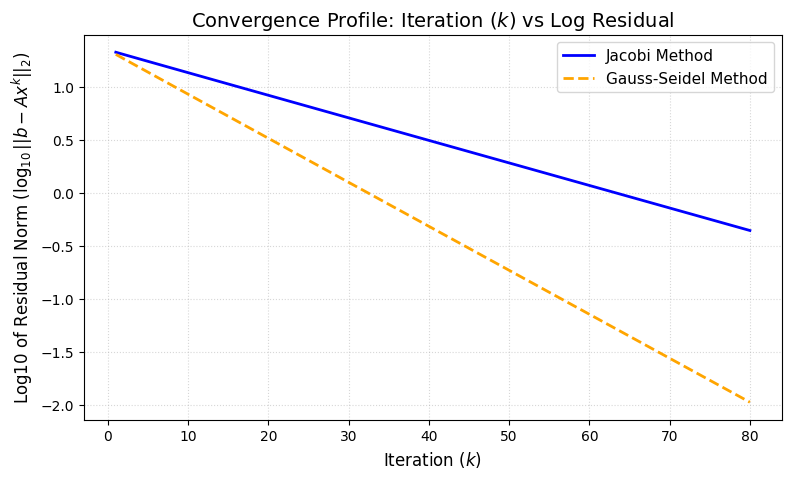

In [71]:
n = 500
main_diag = 2.1 * np.ones(n)
off_diag = -1.0 * np.ones(n - 1)

A = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
b = np.ones(n)


max_k = 80
jacobi_log_residuals = []
seidel_log_residuals = []

# Force extremely low tolerance so the loops never exit early
low_tol = 1e-20 

for k in range(1, max_k + 1):
    # Get the state of x at exactly iteration k
    x_j = solve_jacobi(A, b, tol=low_tol, max_iter=k)
    x_s = solve_seidel(A, b, tol=low_tol, max_iter=k)
    
    # Calculate true residual norm: ||b - Ax^k||2
    res_j = np.linalg.norm(b - np.dot(A, x_j), ord=2)
    res_s = np.linalg.norm(b - np.dot(A, np.array(x_s)), ord=2)
    
    # Log transform the results
    jacobi_log_residuals.append(np.log10(res_j))
    seidel_log_residuals.append(np.log10(res_s))



plt.figure(figsize=(9, 5))
plt.plot(range(1, max_k + 1), jacobi_log_residuals, label='Jacobi Method', color='blue', linewidth=2)
plt.plot(range(1, max_k + 1), seidel_log_residuals, label='Gauss-Seidel Method', color='orange', linestyle='--', linewidth=2)

plt.xlabel('Iteration ($k$)', fontsize=12)
plt.ylabel('Log10 of Residual Norm ($\log_{10}||b - Ax^k||_2$)', fontsize=12)
plt.title('Convergence Profile: Iteration ($k$) vs Log Residual', fontsize=14)
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.legend(fontsize=11)
plt.show()

# PROBLEM 2


In [77]:
import numpy as np


def spectral_radius(M):
    eigvals = np.linalg.eigvals(M)
    return max(abs(eigvals))


def iteration_matrices(A):
    D = np.diag(np.diag(A))
    L = -np.tril(A, -1)
    U = -np.triu(A, 1)

    M_J = np.linalg.inv(D) @ (L + U)
    M_GS = np.linalg.inv(D + L) @ U

    return M_J, M_GS


def solve_jacobi(A, b, tol=1e-6, max_iter=20):
    n = len(b)
    x = np.zeros(n)
    b_norm = np.linalg.norm(b)

    for k in range(1, max_iter + 1):
        x_new = np.zeros(n)
        for i in range(n):
            s = sum(A[i, j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i, i]
        x = x_new

        r = np.linalg.norm(b - A @ x)
        if r / b_norm < tol:
            return x, k, True

    return x, max_iter, False


def solve_seidel(A, b, tol=1e-6, max_iter=20):
    n = len(b)
    x = np.zeros(n)
    b_norm = np.linalg.norm(b)

    for k in range(1, max_iter + 1):
        for i in range(n):
            s = sum(A[i, j] * x[j] for j in range(n) if j != i)
            x[i] = (b[i] - s) / A[i, i]

        r = np.linalg.norm(b - A @ x)
        if r / b_norm < tol:
            return x, k, True

    return x, max_iter, False


A = np.array([[1, 2], [3, 2]], dtype=float)
b = np.array([5, 7], dtype=float)

M_J, M_GS = iteration_matrices(A)
rho_J = spectral_radius(M_J)
rho_GS = spectral_radius(M_GS)

print("Spectral radius of M_J  =", rho_J)
print("Spectral radius of M_GS =", rho_GS)

if rho_J >= 1:
    print("Jacobi will diverge since p(M_J) >= 1")
if rho_GS >= 1:
    print("Gauss-Seidel will diverge since p(M_GS) >= 1")

x_jac, iters_jac, converged_jac = solve_jacobi(A, b)
x_sei, iters_sei, converged_sei = solve_seidel(A, b)

print("\nJacobi result:", x_jac, "converged =", converged_jac)
print("Gauss-Seidel result:", x_sei, "converged =", converged_sei)

Spectral radius of M_J  = 1.7320508075688776
Spectral radius of M_GS = 3.0
Jacobi will diverge since p(M_J) >= 1
Gauss-Seidel will diverge since p(M_GS) >= 1

Jacobi result: [ -59048. -118096.] converged = False
Gauss-Seidel result: [ 4.64904587e+09 -6.97356880e+09] converged = False


# PROBLEM 3


In [67]:
def lu_factorization(A):
    n=A.shape[0]
    L=np.zeros((n,n))
    U=np.copy(A).astype(float)
    P=np.eye(n)
    for i in range(n):
        pivot=np.argmax(np.abs(U[i:,i]))+i # added pivoting
        if(abs(U[pivot,i])<1e-13):
            raise ValueError("singular")
        if pivot!=i:
            U[[i,pivot]]=U[[pivot,i]]
            P[[i,pivot]]=P[[pivot,i]]
            if i>0:
                L[[i,pivot],:i]=L[[pivot,i],:i]
        L[i,i]=1 #added this to diagnols
        for j in range(i+1,n):
            factor=U[j,i]/U[i,i]
            L[j,i]=factor # fixed this factor
            for k in range(i,n):
                U[j,k]=U[j,k]-factor*U[i,k]
    return P,L,U

In [ ]:
def forward_substitution(L,b):
    n=L.shape[0]
    y=np.zeros(n)
    for i in range(n):
        y[i]=b[i]-np.dot(L[i,:i],y[:i])
    return y
#no errors

In [ ]:
def backward_substitution(U,y):
    n=U.shape[0]
    x=np.zeros(n)
    for i in range(n-1,-1,-1): #fixed this range made it run backward
        x[i]=(y[i]-np.dot(U[i,i+1:],x[i+1:]))/U[i,i]
    return x

In [ ]:
def solve_system(A,b):
    E,b1=A,b
    P,L,U=lu_factorization(E)
    Pb=np.dot(P,b1)
    y=forward_substitution(L,Pb)
    x=backward_substitution(U,y)
    return x

In [ ]:
import numpy as np

def matrix_inversion(A):
    # Get the integer dimension size (use index 0)
    n = A.shape[0] 
    identity = np.eye(n)
    columns = []
    
    for i in range(n):
        # Extract the i-th column vector from the identity matrix
        b_vector = identity[:, i] 
        
        # Pass the vector, not just the index loop variable
        x = solve_system(A, b_vector) 
        columns.append(x)
        
    # 4. Combine columns horizontally
    return np.column_stack(columns)


In [ ]:
import numpy as np

def matrix_determinant(A):

    P, L, U = lu_factorization(A)
    
    # Every row swap changes the sign of the determinant by -1
    num_swaps = 0
    P_temp = P.copy().astype(float)
    n = P_temp.shape[0]
    
    for i in range(n):
        # Find where the 1 is in the current row to track the swap
        true_row = np.argmax(P_temp[i, :])
        if true_row != i:
            num_swaps += 1
            # Perform the swap back on our tracking matrix
            P_temp[[i, true_row]] = P_temp[[true_row, i]]
            
    # det(U) = u_11 * u_22 * ... * u_nn
    u_diagonal_product = np.prod(np.diag(U))
    
    # (-1)^s * product(u_ii)
    det = ((-1) ** num_swaps) * u_diagonal_product
    
    return det


In [ ]:
def matrix_analyzer(A):
    det=matrix_determinant(A)
    Ainv=matrix_inversion(A)
    return det,Ainv

In [76]:
matrix=np.array([[1,2,3,4],[2,1,2,3],[3,2,1,2],[4,3,2,1]])
b=np.array([10,8,8,10])
det,Ainv=matrix_analyzer(matrix)
print(Ainv)
print(det)
C2 = np.dot(matrix,Ainv)
print(C2);
print(np.dot(Ainv,b))

[[-0.4  0.5  0.   0.1]
 [ 0.5 -1.   0.5  0. ]
 [ 0.   0.5 -1.   0.5]
 [ 0.1  0.   0.5 -0.4]]
-20.0
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.77555756e-17  1.00000000e+00  0.00000000e+00 -1.11022302e-16]
 [-1.66533454e-16  0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [-8.32667268e-17  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[1. 1. 1. 1.]


In [ ]:
a=np.array([[1,2,3],[4,5,6],[7,8,9]])
b=np.array([6,15,24])
eta=[1e-1,1e-4,1e-7,1e-12,0]
for i in eta:
    a1=np.copy(a).astype(float)
    b1=np.copy(b).astype(float)
    a1[2][2]+=i;
    b1[2]+=i;
    x=solve_system(a1,b1)
    det,ainv=matrix_analyzer(a1)
    print(x)
    print(det)
    print(np.dot(ainv,b))
    

[1. 1. 1.]
-0.29999999999999827
[1. 1. 1.]
-0.00029999999999996696
[1.00000002 0.99999996 1.00000002]
-2.999999968444911e-07
[0.99755935 1.0048813  0.99755935]
-3.0022651031913483e-12


ValueError: singular